In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("results/acc_df.csv")

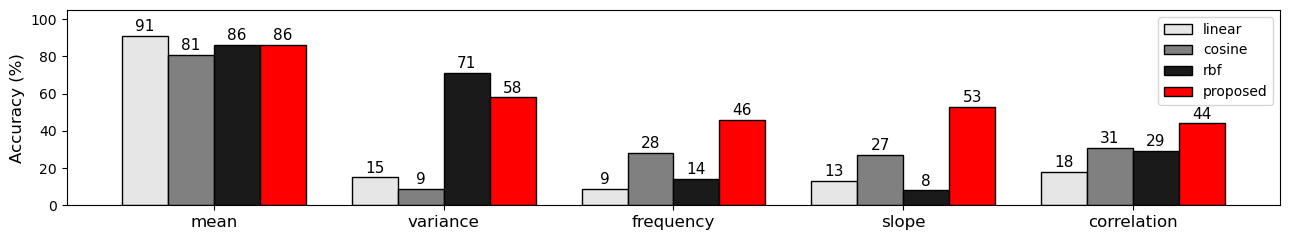

In [3]:
# Accuracy types and models
accuracy_types = ['mean', 'variance', 'frequency', 'slope', 'correlation']
models = ['linear', 'cosine', 'rbf', 'proposed']

# Reasonable accuracies for changepoint detection (0-100)
data = {
    'linear':   df[df['model'] == 'linear'].to_numpy()[0][1:],
    'cosine':   df[df['model'] == 'cosine'].to_numpy()[0][1:],
    'rbf':      df[df['model'] == 'rbf'].to_numpy()[0][1:],
    'proposed': df[df['model'] == 'proposed'].to_numpy()[0][1:]
}

# Create DataFrame
df_final = pd.DataFrame(data, index=accuracy_types)

# Plotting
x = np.arange(len(accuracy_types))
width = 0.2  # width of each bar

fig, ax = plt.subplots(figsize=(13, 2.5))

# Colors: greyscale for all except proposed
colors = ['0.9', '0.5', '0.1', 'red']

for i, model in enumerate(models):
    bars = ax.bar(x + i*width - width*1.5, 100*df_final[model], width, label=model, color=colors[i], edgecolor='black')
    # Add numbers on top
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.0f}', ha='center', va='bottom', fontsize=11)

# Labels and titles
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(accuracy_types, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()